# Bank Marketing dataset: initial EDA

This notebook presents an initial exploratory data analysis of the Bank Marketing dataset from the UCI Machine Learning Repository.

According to the dataset documentation, the data is related to direct marketing campaigns of a Portuguese banking institution. The dataset contains 16 input features and 1 target variable, resulting in 17 columns in total. It includes both categorical and numerical attributes.

In [1]:
import pandas as pd

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
#print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 

df = pd.concat([X, y], axis=1)

if "day_of_week" in df.columns:
    df = df.rename(columns={"day_of_week": "day"})

           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

In [2]:
df.head(100)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,36,management,married,tertiary,no,101,yes,yes,NaN,5,may,426,1,-1,0,NaN,no
96,55,blue-collar,married,secondary,no,383,no,no,NaN,5,may,287,1,-1,0,NaN,no
97,60,retired,married,tertiary,no,81,yes,no,NaN,5,may,101,1,-1,0,NaN,no
98,39,technician,married,secondary,no,0,yes,no,NaN,5,may,203,1,-1,0,NaN,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        44923 non-null  object
 2   marital    45211 non-null  object
 3   education  43354 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    32191 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   8252 non-null   object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Dataset overview

The dataset contains 45211 rows and 17 columns.

It includes:
- **7 numerical columns**
- **6 multi-class categorical columns**
- **4 binary categorical columns** (`default`, `housing`, `loan`, and `y`)

(day is categorical but represented by integers.)

The first 16 columns are input features, while the last column, `y`, is the target variable.

## Missing values

According to the dataset description, several fields may contain `unknown` values. In the dataframe returned by `ucimlrepo`, these appear as `NaN` values in some columns.

The next step is to verify this directly in the loaded dataset and quantify the amount of missing data in each column.

In [4]:
columns = [
    "age", "job", "marital", "education", "default", "balance",
    "housing", "loan", "contact", "day", "month", "duration",
    "campaign", "pdays", "previous", "poutcome", "y"
]

for col in columns:
    print('Number of missing values at column', col, ':', df[col].isna().sum(), 'Percentage:', df[col].isna().mean() * 100, '%')

Number of missing values at column age : 0 Percentage: 0.0 %
Number of missing values at column job : 288 Percentage: 0.6370131162770122 %
Number of missing values at column marital : 0 Percentage: 0.0 %
Number of missing values at column education : 1857 Percentage: 4.1074074893278185 %
Number of missing values at column default : 0 Percentage: 0.0 %
Number of missing values at column balance : 0 Percentage: 0.0 %
Number of missing values at column housing : 0 Percentage: 0.0 %
Number of missing values at column loan : 0 Percentage: 0.0 %
Number of missing values at column contact : 13020 Percentage: 28.798301298356595 %
Number of missing values at column day : 0 Percentage: 0.0 %
Number of missing values at column month : 0 Percentage: 0.0 %
Number of missing values at column duration : 0 Percentage: 0.0 %
Number of missing values at column campaign : 0 Percentage: 0.0 %
Number of missing values at column pdays : 0 Percentage: 0.0 %
Number of missing values at column previous : 0 Per

The missing values are concentrated in 4 columns:

- `job`: **288** missing values (**0.64%**)
- `education`: **1,857** missing values (**4.11%**)
- `contact`: **13,020** missing values (**28.80%**)
- `poutcome`: **36,959** missing values (**81.75%**)

All other columns are complete.

This is an important preprocessing issue, because these missing values mostly correspond to `unknown` or unavailable campaign information rather than measurement errors. Depending on the synthetic-data baseline, they may need to be preserved as an explicit missing category, or handled through preprocessing before modeling.

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Numerical columns

The numerical summary shows that the main continuous or count-based variables have plausible ranges.

A few initial observations:
- `age` ranges from **18** to **95**, which is reasonable for this dataset.
- `balance` ranges from **-8,019** to **102,127**, showing both negative balances and a very wide spread.
- `day` ranges from **1** to **31**, which is consistent with the last contact day of the month.
- `duration` ranges from **0** to **4,918** seconds and is likely to be strongly right-skewed.
- `campaign` ranges from **1** to **63**, suggesting that a small number of clients were contacted many times.
- `pdays` has quartiles equal to **-1**, which indicates that many clients were not contacted in a previous campaign.
- `previous` also has quartiles equal to **0**, so most clients had no earlier contacts before the current campaign.

At this stage, there are no obvious impossible values in the numerical columns, but several variables appear skewed or include sentinel values that should be kept in mind during preprocessing.

In [6]:
categ = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "y"]

for cat in categ:
    print("List of attributes of category", cat, ":", df[cat].unique())
    print(df[cat].value_counts(dropna=False))
    print()

List of attributes of category job : ['management' 'technician' 'entrepreneur' 'blue-collar' nan 'retired'
 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
NaN               288
Name: count, dtype: int64

List of attributes of category marital : ['married' 'single' 'divorced']
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

List of attributes of category education : ['tertiary' 'secondary' nan 'primary']
education
secondary    23202
tertiary     13301
primary       6851
NaN           1857
Name: count, dtype: int64

List of attributes of category default : ['no' 'yes']
default
no     44396
yes      815
Name: count, dtype: int64

List of attributes of category housing : ['yes' 'no']

## Sensitive attributes

No explicit sensitive attributes such as sex or race are present in this dataset.

# Target variable

The target column, `y`, is imbalanced.

- **no**: 39,922 rows
- **yes**: 5,289 rows

This means that the positive class (`yes`) represents only about **11.7%** of the dataset. This class imbalance is important for both modeling and evaluation, since a synthetic data generator should preserve the minority subscription class without collapsing it into the dominant `no` category.


In [7]:
df.duplicated().sum()

np.int64(0)

## Duplicate rows

A check for exact duplicate rows shows that the dataset contains **no duplicated records**.

This means duplicates do not appear to be a preprocessing concern for this dataset, so the main cleaning issues are more related to missing values, imbalance, and skewed distributions.

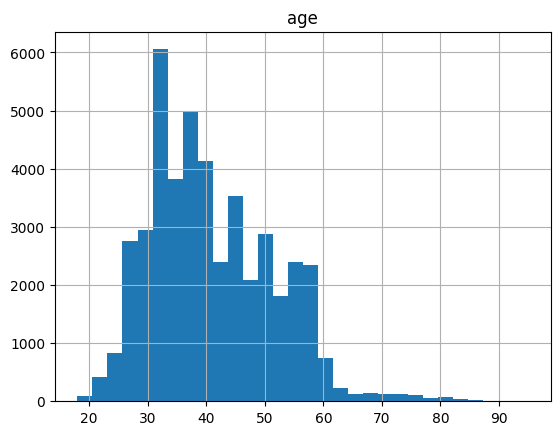

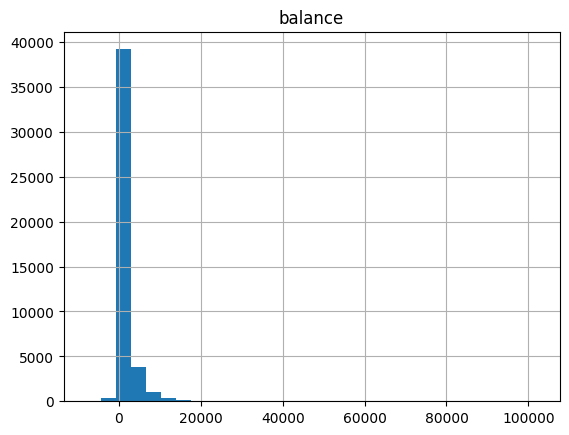

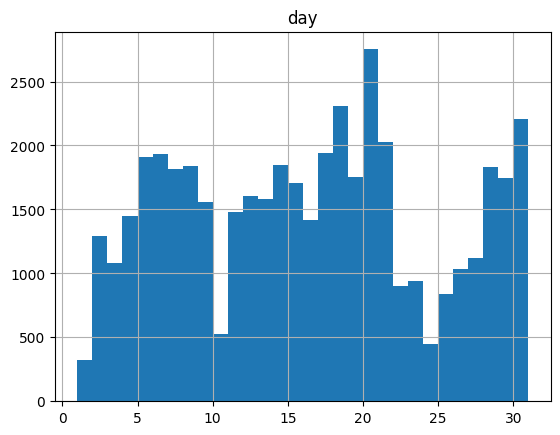

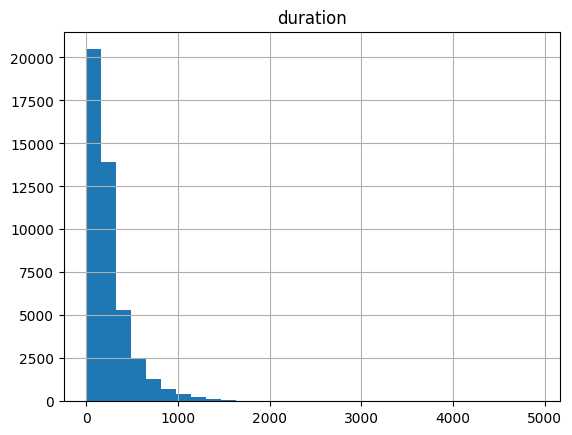

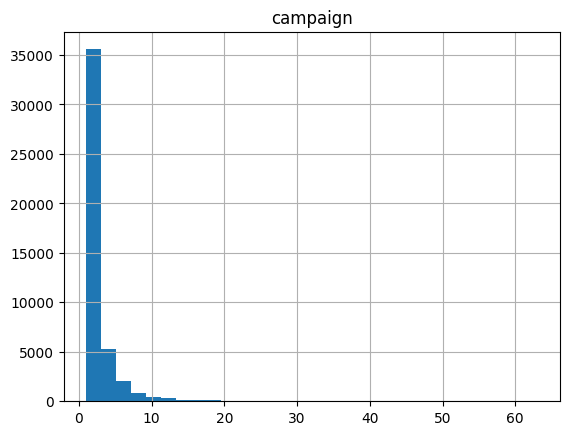

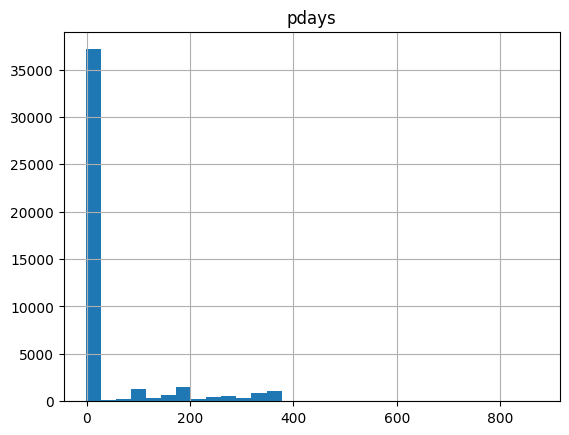

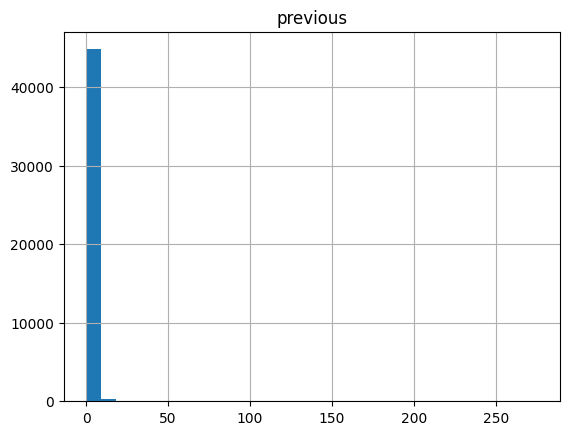

In [8]:
import matplotlib.pyplot as plt

numer = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

for n in numer:
    df[n].hist(bins=30)
    plt.title(n)
    plt.show()

## Histograms

The histograms confirm that the numerical variables follow different types of distributions.

- `age` is concentrated mostly in the adult and middle-age range, then declines toward older ages.
- `balance` is strongly right-skewed, with many lower balances, some negative values, and a small number of very large balances.
- `duration` is also strongly right-skewed, with many shorter calls and a smaller number of much longer calls.
- `campaign` is concentrated at low values, while a small number of observations extend into a long tail.
- `pdays` shows a very large spike at **-1**, reflecting clients who were not previously contacted.
- `previous` is highly concentrated at **0**, again showing that many clients had no earlier campaign contacts.

Overall, the histograms suggest that several numerical features are not normally distributed and that some contain heavy skew or sentinel-value effects. This is important to keep in mind when selecting preprocessing steps and evaluating whether synthetic data preserves the original feature distributions.

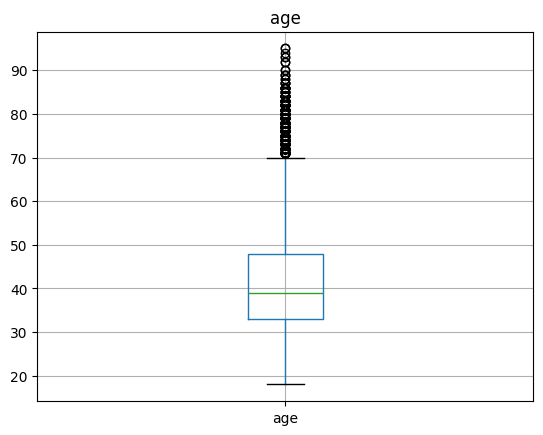

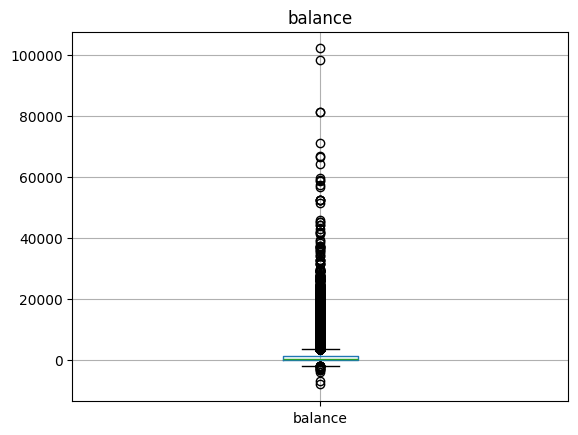

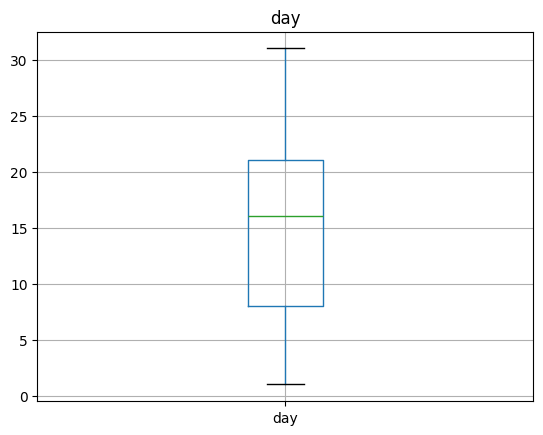

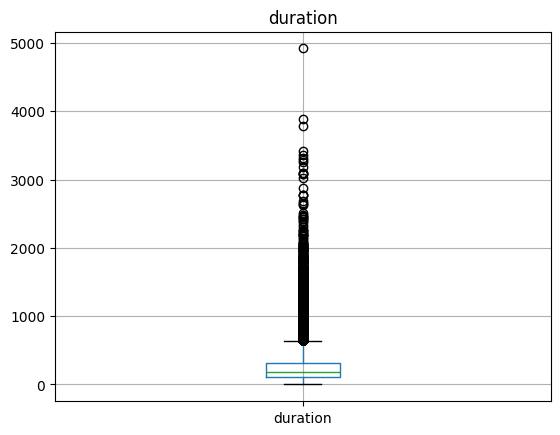

In [9]:
boxp_numer = ['age', 'balance', 'day', 'duration']

for n in boxp_numer:
    df.boxplot(n)
    plt.title(n)
    plt.show()

## Boxplots

The boxplots support the same main conclusions from the histograms and make the spread and outliers more visible.

These boxplots indicate that several numerical variables contain strong asymmetry or extreme values. This does not necessarily mean that the values are invalid, but it does mean the data is heterogeneous and should be handled carefully during preprocessing and synthetic data evaluation.

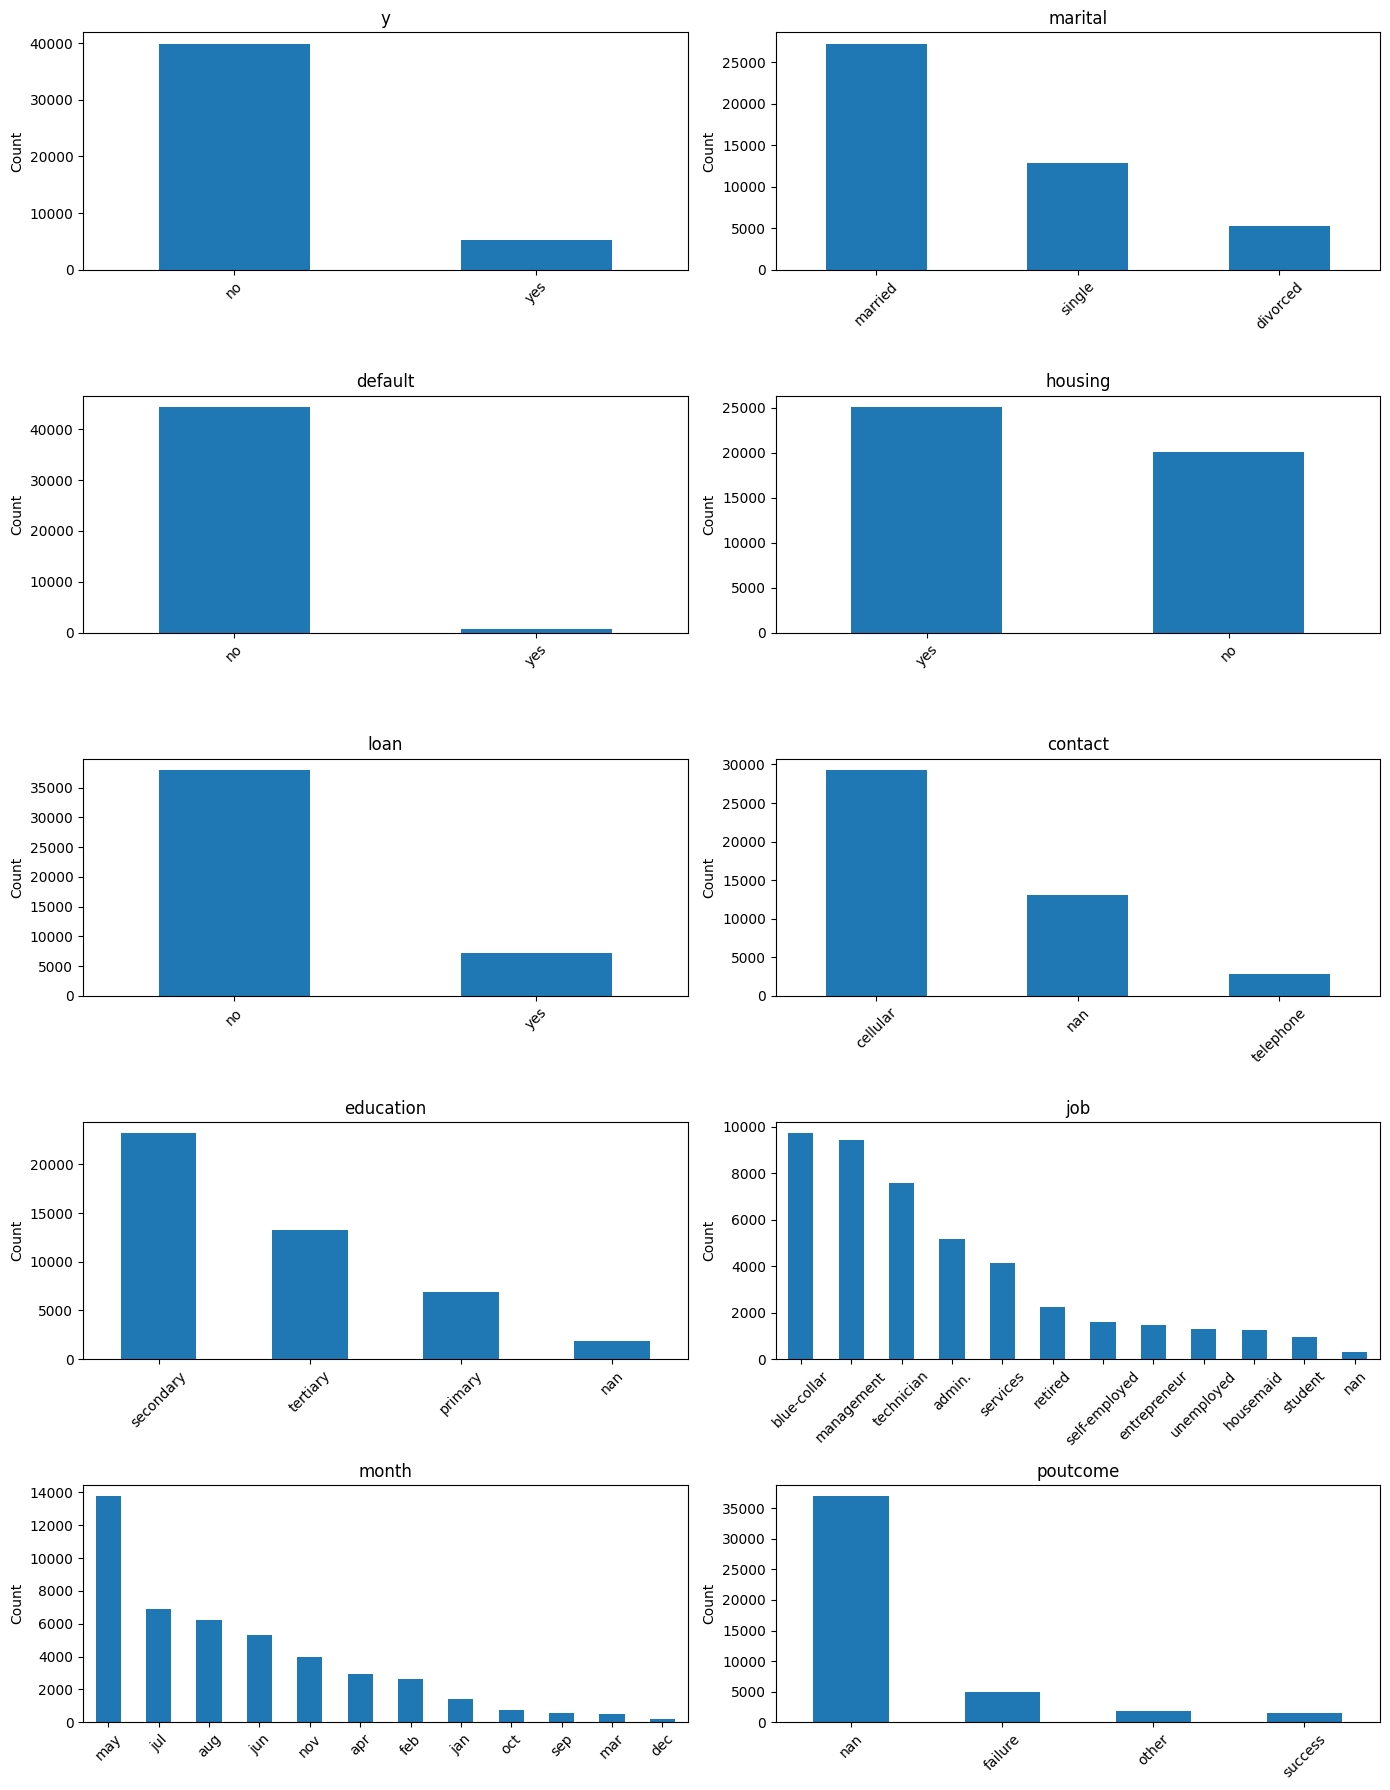

In [10]:
categ_bar = ["y", "marital", "default", "housing", "loan", "contact", "education", "job", "month", "poutcome"]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, categ_bar):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categ_bar):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Bar charts

The bar charts make the imbalance patterns in the categorical variables easier to see.

- The `y` chart confirms that the target variable is imbalanced, with `no` clearly dominating `yes`.
- The `default` chart is heavily dominated by `no`.
- The `housing` and `loan` charts show that these binary variables are also imbalanced, especially `loan`.
- The `contact` and `poutcome` charts reveal large missing or `unknown` portions.
- The `month` chart is uneven, with a few months dominating the observations and some months contributing only a small share.
- The `education` and `job` charts show that a few categories account for much of the dataset, while several smaller categories remain underrepresented.

These patterns are important because synthetic data generators may reproduce the dominant groups well while performing worse on smaller categories or on the missing-category structure.

<Axes: >

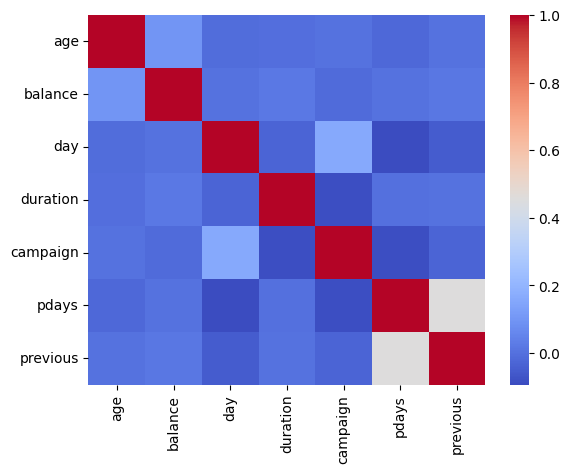

In [11]:
import seaborn as s
s.heatmap(df[numer].corr(), cmap="coolwarm")

## Correlation

The numerical variables in the Bank Marketing dataset are not expected to be strongly linearly correlated overall.

The most notable relationship is likely between `pdays` and `previous`, since both describe earlier campaign contact history.

In [12]:
rare_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "y"]

for col in rare_cols:
    print(df[col].value_counts().sort_index(), df[col].value_counts(normalize=True).sort_index() * 100,'\n')

job
admin.           5171
blue-collar      9732
entrepreneur     1487
housemaid        1240
management       9458
retired          2264
self-employed    1579
services         4154
student           938
technician       7597
unemployed       1303
Name: count, dtype: int64 job
admin.           11.510807
blue-collar      21.663736
entrepreneur      3.310108
housemaid         2.760279
management       21.053803
retired           5.039735
self-employed     3.514903
services          9.246934
student           2.088017
technician       16.911159
unemployed        2.900519
Name: proportion, dtype: float64 

marital
divorced     5207
married     27214
single      12790
Name: count, dtype: int64 marital
divorced    11.517109
married     60.193316
single      28.289576
Name: proportion, dtype: float64 

education
primary       6851
secondary    23202
tertiary     13301
Name: count, dtype: int64 education
primary      15.802463
secondary    53.517553
tertiary     30.679983
Name: proportion, dtype

## Rare categories

Rare categories are most visible in default, contact, and month. In default, the yes category is very rare (1.80%). In contact, telephone is much less frequent than cellular (9.03%). In month, several months occur only rarely, especially dec (0.47%), mar (1.06%), sep (1.28%), and oct (1.63%).

job also contains some relatively small groups, such as student (2.09%), housemaid (2.76%), and unemployed (2.90%), but these are less extreme than the rare categories seen in default and month.

## Initial preprocessing considerations

Based on this EDA, the main preprocessing issues are:
- handling missing values in `job`, `education`, `contact`, and `poutcome`
- encoding categorical variables appropriately for baseline method(s)
- paying attention to class and group imbalance in `y`, `default`, `contact`, and some `month` categories
- considering whether rare categories in `default`, `contact`, `month`, and some `job` groups should be merged
- monitoring highly skewed numerical variables such as `balance`, `duration`, `campaign`, `pdays`, and `previous`